<a href="https://colab.research.google.com/github/cafauzi13/Sentiment-Analysis-M-Paspor-PBA/blob/main/Tugas1_Artikel_summarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import Dependencies

In [1]:
# Install library pendukung
!pip install Sastrawi

import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk.download('punkt')
nltk.download('punkt_tab')

# Inisialisasi Sastrawi untuk teks Indonesia
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Fungsi pembantu untuk visualisasi
def plot_tfidf(tfidf_df, title):
    plt.figure(figsize=(10, 6))
    plt.bar(tfidf_df['Feature'], tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Tugas 1A: Danantara

In [2]:
sentence2 = """Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.

Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.

Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.

"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.

Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. Buka peluang investasi sektor strategis
Dana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.

"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.

Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.

"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar. Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola nvestasi secara profesional dan akuntabel," ungkapnya.

Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia. Jangan lupa ikuti update berita lainnya dan follow  akun
Google News Metrotvnews.com dan Channel WhatsApp Metro TV

(Eko Nordiansyah)"""

### Text Preprocessing

In [3]:
# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)
print("Tokenized sentences:")
for i, sent in enumerate(sent_token2):
    print(f"{i+1}. {sent}")

Tokenized sentences:
1. Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
2. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
3. Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.
4. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
5. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.
6. "Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertuli

In [4]:
# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

In [5]:
# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)


Cleaned sentences (Indonesian stop words removed):
Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi telah disepakati Qatar.
Kesepakatan Indonesia Qatar merupakan buah kunjungan resmi Presiden Prabowo Subianto Doha.
Pemerintah Republik Indonesia Pemerintah Qatar menggelar diskusi menyepakati kemitraan strategis (co-partnership) pengelolaan dana investasi Indonesia akan berfokus berbagai sektor pembangunan.
Salah satu hasil utama kunjungan tersebut untuk membentuk dana investasi bersama senilai USD4 miliar.
Dana akan difokuskan pengembangan berbagai sektor antaranya termasuk tidak terbatas hilirisasi industri, energi terbarukan, fasilitas kesehatan Indonesia.
"Kami menyambut baik kepercayaan diberikan Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani keterangan tertulis, Selasa, 15 April 2025.
Presiden Prabowo menyampaikan masing-masing negara berkontribusi sebesar USD2 m

In [6]:
# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

print("\nShape of the Feature Matrix:")
print(features.shape)




Shape of the Feature Matrix:
(16, 182)


In [7]:
# Feature Names (Vocabulary)
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in vocabulary):")
print(feature_names)




Feature Names (Words in vocabulary):
['15' '2025' 'adalah' 'akan' 'akun' 'akuntabel' 'anagata' 'antaranya'
 'april' 'authority' 'badan' 'baik' 'berbagai' 'berfokus' 'berita'
 'berkelanjutan' 'berkontribusi' 'berorientasi' 'bersama' 'berskala'
 'besar' 'bpi' 'buah' 'buka' 'bukti' 'ceo' 'channel' 'co' 'com' 'dampak'
 'dana' 'danantara' 'daya' 'diberikan' 'didanai' 'difokuskan' 'diharapkan'
 'dikelola' 'dipandang' 'diplomatik' 'disepakati' 'diskusi' 'doha' 'dunia'
 'eko' 'ekonomi' 'energi' 'fasilitas' 'fokus' 'follow' 'global' 'google'
 'hanya' 'hasil' 'hilirisasi' 'hubungan' 'ikuti' 'indonesia' 'industri'
 'ini' 'inisiatif' 'internasional' 'investasi' 'investment' 'jakarta'
 'jangan' 'juga' 'kami' 'kapasitas' 'kata' 'kedua' 'kelembagaan' 'kelola'
 'kemitraan' 'kepercayaan' 'kerja' 'kesehatan' 'kesejahteraan'
 'kesepakatan' 'keterangan' 'kolaborasi' 'konkret' 'kontribusi'
 'kunjungan' 'lain' 'lainnya' 'langkah' 'lanjut' 'lebih' 'lupa' 'mandat'
 'masing' 'masyarakat' 'melalui' 'memastikan

In [8]:
# Helper function to get TF-IDF for a specific sentence
def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
    sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
    tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
    tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
    return tfidf_df


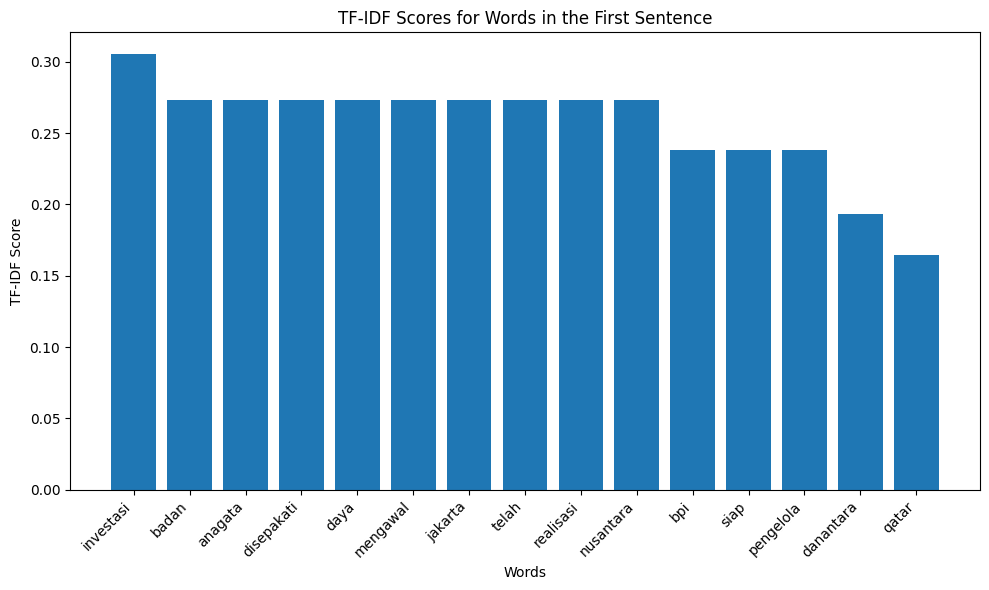

In [9]:

# Visualizing TF-IDF Scores for the First Sentence
if cleaned_sentences:
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Sentence")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Calculate Sentence Score


**Average TF-IDF Score for Each Sentence:**
- Sentence 1
  Sum of TF-IDF scores: 3.8371638194135773
  Number of words: 15
  Average TF-IDF score: 0.2558109212942385
- Sentence 2
  Sum of TF-IDF scores: 3.26289358846549
  Number of words: 11
  Average TF-IDF score: 0.2966266898604991
- Sentence 3
  Sum of TF-IDF scores: 4.187001878090137
  Number of words: 19
  Average TF-IDF score: 0.2203685198994809
- Sentence 4
  Sum of TF-IDF scores: 3.682269126752843
  Number of words: 14
  Average TF-IDF score: 0.2630192233394888
- Sentence 5
  Sum of TF-IDF scores: 4.066194385981777
  Number of words: 17
  Average TF-IDF score: 0.23918790505775156
- Sentence 6
  Sum of TF-IDF scores: 4.928302699223024
  Number of words: 25
  Average TF-IDF score: 0.19713210796892094
- Sentence 7
  Sum of TF-IDF scores: 3.123269943251901
  Number of words: 11
  Average TF-IDF score: 0.28393363120471826
- Sentence 8
  Sum of TF-IDF scores: 3.4082170861903323
  Number of words: 12
  Average TF-IDF score: 0.28401809

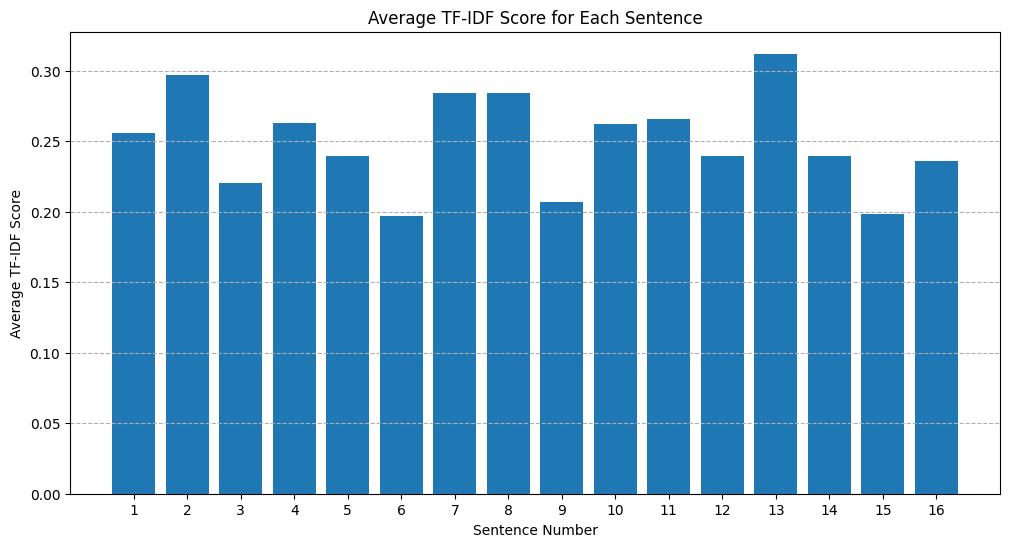

In [10]:
# Variable initialization
sent_index = 0
sent_scores = []

# Calculate average TF-IDF score for each sentence
print("\n**Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print("  Sum of TF-IDF scores:", sent_score)
    print("  Number of words:", sent_length)
    print("  Average TF-IDF score:", avg_score)
    sent_scores.append(avg_score)
    sent_index += 1

# Visualize Average Score Histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.show()

### Define Threshold

In [11]:
# Calculate the threshold
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0
print("\nThreshold (Average of Sentence Scores):", threshold)

# Final summary initialization
final_summ = ""

# Get summary sentences (logic: score >= threshold)
print("\n**Summary Sentences:**")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + "\n" + sent_token2[index]
        print("- ", sent_token2[index])

print("\n**Final Summarization Result:**")
print(final_summ.strip())


Threshold (Average of Sentence Scores): 0.24996411348685135

**Summary Sentences:**
-  Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
-  Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
-  Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
-  Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.
-  Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.
-  "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.
-  Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.
-  "K

# TUGAS 1B: Manchester


In [12]:
sentence = """
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.

“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.

City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.

“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.

“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""

### Preprocessing - Tokenization

In [13]:
# Sentence tokenization
sent_token = sent_tokenize(sentence)
print("Tokenized sentences:")
for i, sent in enumerate(sent_token):
    print(f"{i+1}. {sent}")

# Karena bahasa Inggris, kita tidak perlu Sastrawi.
# Kita langsung lanjut ke tahap TF-IDF dengan parameter stop_words='english'

Tokenized sentences:
1. 
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
2. Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
3. The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
4. “We’ve shown over the past 12 months we are the best team in the world.
5. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.
6. “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
7. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside thes

### TF-IDF Training & Matrix Analysis


Feature Names (English Words):
['12' '40' '72nd' '88th' 'according' 'achieved' 'aké' 'alongside'
 'amazing' 'arabia' 'ask' 'attempted' 'available' 'best' 'better'
 'biggest' 'boasts' 'boss' 'brazilian' 'break' 'brilliant' 'broke'
 'calendar' 'came' 'cannoned' 'capped' 'captain' 'champion' 'champions'
 'charged' 'chest' 'city' 'clinical' 'close' 'club' 'completed'
 'consistency' 'continued' 'corner' 'couldn' 'cross' 'cup' 'currently'
 'dangerous' 'defence' 'defender' 'deflected' 'dismantling' 'distance'
 'dominance' 'doubled' 'effort' 'ended' 'england' 'english' 'everton'
 'exchanges' 'fa' 'face' 'faces' 'fans' 'far' 'fight' 'final' 'finish'
 'fixture' 'fluminense' 'foden' 'forward' 'fourth' 'free' 'friday' 'game'
 'got' 'guardiola' 'having' 'heads' 'highly' 'history' 'hold' 'home'
 'honestly' 'honour' 'incredible' 'jigsaw' 'julián' 'just' 'kyle'
 'largely' 'lead' 'league' 'left' 'let' 'lift' 'look' 'major' 'makes'
 'managed' 'manager' 'manchester' 'marcelo' 'match' 'matter' 'mentality

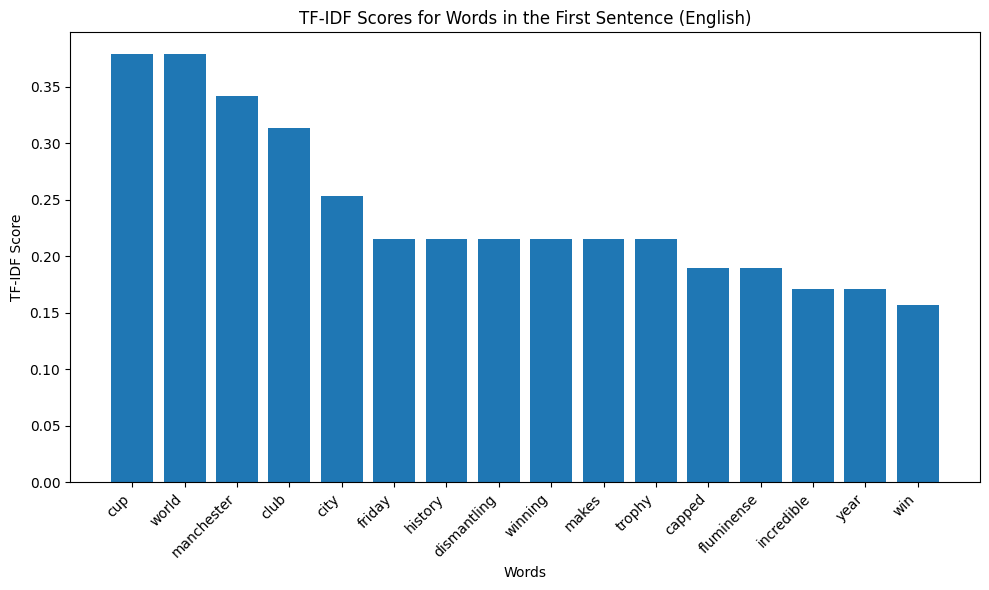

In [14]:
# Training TF-IDF Vectorizer (Menggunakan stop_words English)
vectorizer = TfidfVectorizer(stop_words='english')
features = vectorizer.fit_transform(sent_token)

# Feature Names (Vocabulary setelah filter stopwords)
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (English Words):")
print(feature_names)

# Helper function
def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
    sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
    tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
    tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
    return tfidf_df

# Visualizing TF-IDF Scores for Sentence 1
if sent_token:
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Sentence (English)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Calculate Sentence Score & Visualization


**Average TF-IDF Score for Each Sentence:**
- Sentence 1
  Sum: 3.8372, Words: 16, Avg: 0.2398
- Sentence 2
  Sum: 4.2077, Words: 19, Avg: 0.2215
- Sentence 3
  Sum: 3.7128, Words: 14, Avg: 0.2652
- Sentence 4
  Sum: 2.8148, Words: 8, Avg: 0.3519
- Sentence 5
  Sum: 3.5887, Words: 13, Avg: 0.2761
- Sentence 6
  Sum: 2.4238, Words: 6, Avg: 0.4040
- Sentence 7
  Sum: 2.6415, Words: 7, Avg: 0.3774
- Sentence 8
  Sum: 3.2861, Words: 11, Avg: 0.2987
- Sentence 9
  Sum: 3.6036, Words: 13, Avg: 0.2772
- Sentence 10
  Sum: 3.6006, Words: 13, Avg: 0.2770
- Sentence 11
  Sum: 3.9747, Words: 16, Avg: 0.2484
- Sentence 12
  Sum: 2.9960, Words: 9, Avg: 0.3329
- Sentence 13
  Sum: 3.4591, Words: 12, Avg: 0.2883
- Sentence 14
  Sum: 3.1227, Words: 10, Avg: 0.3123
- Sentence 15
  Sum: 1.4113, Words: 2, Avg: 0.7056
- Sentence 16
  Sum: 3.4184, Words: 13, Avg: 0.2630
- Sentence 17
  Sum: 3.6801, Words: 14, Avg: 0.2629
- Sentence 18
  Sum: 4.5066, Words: 21, Avg: 0.2146
- Sentence 19
  Sum: 2.9947, Word

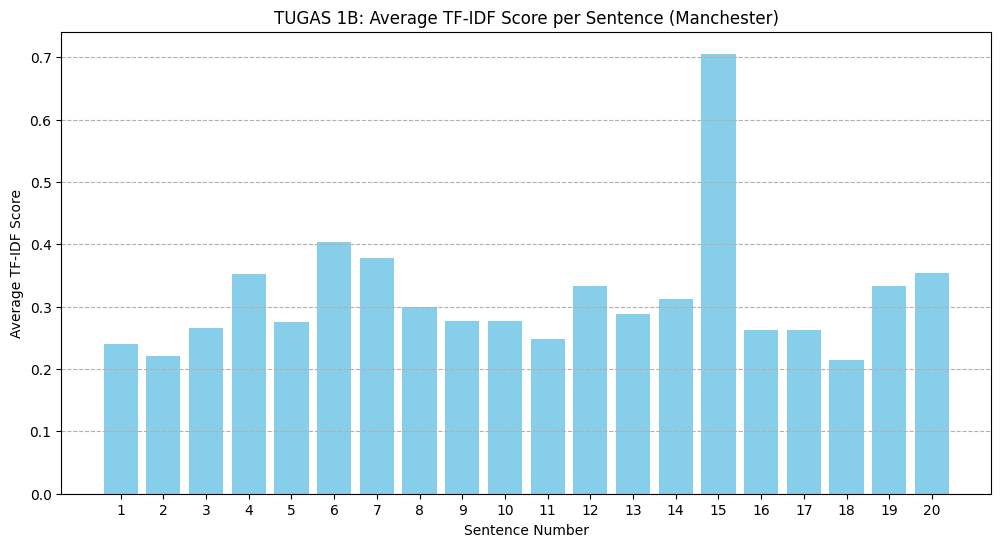

In [15]:
# Variable initialization
sent_index = 0
sent_scores = []

# Calculate average TF-IDF score for each sentence
print("\n**Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print(f"  Sum: {sent_score:.4f}, Words: {sent_length}, Avg: {avg_score:.4f}")
    sent_scores.append(avg_score)
    sent_index += 1

# Visualize Average Score Histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores, color='skyblue')
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("TUGAS 1B: Average TF-IDF Score per Sentence (Manchester)")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.show()

### Define Threshold & Summarization Result

In [16]:
# Calculate the threshold (average of all scores)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0
print("\nThreshold (Average of Sentence Scores):", threshold)

# Get summary sentences (score >= threshold)
final_summ = ""
print("\n**Summary Sentences (Manchester City News):**")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + "\n" + sent_token[index]
        print("- ", sent_token[index])

print("\n**Final Summarization Result (1B):**")
print(final_summ.strip())


Threshold (Average of Sentence Scores): 0.31514140188014117

**Summary Sentences (Manchester City News):**
-  “We’ve shown over the past 12 months we are the best team in the world.
-  “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
-  I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
-  Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
-  “As a manager it is what I am most proud of; that we are always there.
-  The champion heads back to England where it faces a tough title defence in the Premier League.
-  It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.

**Final Summarization Result (1B):**
“We’ve shown over the past 12 months we are the best team in the world.
“To win these five trophies – for me, the five biggest prizes available to us – is incredible.
I am so proud to have been

# Tugas 1C: Replace Artikel

Sumber berita :
https://www.cnbcindonesia.com/news/20231121154850-4-490788/pungut-salur-iuran-batu-bara-bakal-dikelola-oleh-3-bank-ri

### Define Document

In [25]:
sentence3 = """Kementerian Energi dan Sumber Daya Mineral (ESDM) menyampaikan terdapat tiga Bank BUMN yang akan ditunjuk menjadi Mitra Instansi Pengelola (MIP) yang bertugas memungut iuran batu bara perusahaan tambang. Ketiganya yakni Bank Mandiri, Bank BNI, dan Bank BRI.
Menteri ESDM Arifin Tasrif memastikan pembentukan mitra instansi pengelola saat ini masih menunggu proses finalisasi draft rancangan peraturan presiden (perpres). Namun dalam pengelolaan dana kompensasi batu bara (DKB), pemerintah telah menyiapkan 3 Bank BUMN.
"Calon BUMN yang akan ditunjuk sebagai mitra instansi pengelola untuk kegiatan pemungutan dan penyaluran DKB yaitu 3 bank, Bank Mandiri Bank BNI kemudian Bank BRI," ujar Arifin dalam Rapat Kerja bersama Komisi VII DPR RI, Selasa (21/11/2023).
Menurut Arifin, seluruh calon MIP sepakat untuk menggunakan dashboard sistem yang di develop oleh Bank Mandiri (sistem eDKB), dan sepakat tidak mencantumkan leading bank.
Sementara itu, petunjuk teknis (juknis) alur kerja dan tanggung jawab antara Instansi Pengelola (IP) dan MIP secara detail akan diatur dalam (RPermen/RKepmen ESDM).
Adapun, pada saat Pemungutan DKB tetap dikenakan kewajiban royalti, sedangkan pada saat Penyaluran DKB pada pemasok batubara dalam negeri dikenakan kewajiban PPN. Sistem e-DKB akan diintegrasikan dengan sistem e-PNBP dalam skema pelaksanaan pemungutan dan penyaluran DKB.
"Batu bara coking coal dikecualikan terhadap kewajiban MIP namun tetap diwajibkan DMO sehingga masih perlu pengaturan terkait kewajiban denda dan kompensasi atas DMO," ujar Arifin."""

### Preprocessing - Tokenization

In [26]:
# Sentence tokenization
sent_token3 = sent_tokenize(sentence3)
print(f"Jumlah kalimat terdeteksi: {len(sent_token3)}")

# Preprocessing menggunakan Sastrawi (Stopword Removal)
cleaned_sentences3 = [stopword_remover.remove(sent) for sent in sent_token3]

print("\nKalimat setelah dibersihkan (Sastrawi):")
for i, clean_sent in enumerate(cleaned_sentences3):
    print(f"{i+1}. {clean_sent}")

Jumlah kalimat terdeteksi: 10

Kalimat setelah dibersihkan (Sastrawi):
1. Kementerian Energi Sumber Daya Mineral (ESDM) menyampaikan terdapat tiga Bank BUMN akan ditunjuk menjadi Mitra Instansi Pengelola (MIP) bertugas memungut iuran batu bara perusahaan tambang.
2. Ketiganya Bank Mandiri, Bank BNI, Bank BRI.
3. Menteri ESDM Arifin Tasrif memastikan pembentukan mitra instansi pengelola ini menunggu proses finalisasi draft rancangan peraturan presiden (perpres).
4. Namun pengelolaan dana kompensasi batu bara (DKB), pemerintah menyiapkan 3 Bank BUMN.
5. "Calon BUMN akan ditunjuk mitra instansi pengelola kegiatan pemungutan penyaluran DKB 3 bank, Bank Mandiri Bank BNI kemudian Bank BRI," ujar Arifin Rapat Kerja bersama Komisi VII DPR RI, Selasa (21/11/2023).
6. Menurut Arifin, seluruh calon MIP sepakat menggunakan dashboard sistem di develop Bank Mandiri (sistem eDKB), sepakat mencantumkan leading bank.
7. Sementara itu, petunjuk teknis (juknis) alur kerja tanggung jawab Instansi Pengelol

###

In [27]:
# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer3 = TfidfVectorizer()
features3 = vectorizer3.fit_transform(cleaned_sentences3)

print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features3)

print("\nShape of the Feature Matrix (Sentences, Unique Words):")
print(features3.shape)

# Feature Names (Kamus kata yang sudah difilter)
feature_names3 = vectorizer3.get_feature_names_out()
print("\nFeature Names (Vocabulary):")
print(feature_names3)




TF-IDF Feature Matrix (Sparse) on cleaned sentences:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 163 stored elements and shape (10, 117)>
  Coords	Values
  (0, 49)	0.2243073256053346
  (0, 38)	0.2243073256053346
  (0, 106)	0.2243073256053346
  (0, 22)	0.2243073256053346
  (0, 69)	0.2243073256053346
  (0, 39)	0.1668239722503805
  (0, 67)	0.2243073256053346
  (0, 111)	0.2243073256053346
  (0, 114)	0.2243073256053346
  (0, 8)	0.1331983661220287
  (0, 16)	0.1668239722503805
  (0, 4)	0.19068171947698276
  (0, 31)	0.19068171947698276
  (0, 63)	0.2243073256053346
  (0, 71)	0.1668239722503805
  (0, 42)	0.14831846581708308
  (0, 81)	0.14831846581708308
  (0, 70)	0.14831846581708308
  (0, 13)	0.2243073256053346
  (0, 60)	0.2243073256053346
  (0, 45)	0.2243073256053346
  (0, 10)	0.1668239722503805
  (0, 9)	0.1668239722503805
  (0, 87)	0.2243073256053346
  (0, 107)	0.2243073256053346
  :	:
  (8, 83)	0.2382355906718655
  (8, 104)	0.5446120417483625
  (8, 28)	0.32032559521727527
 


TF-IDF values for the first sentence (sorted):
          Feature    TF-IDF
13       bertugas  0.224307
38         energi  0.224307
22           daya  0.224307
69        mineral  0.224307
67   menyampaikan  0.224307
60       memungut  0.224307
63        menjadi  0.224307
45          iuran  0.224307
49    kementerian  0.224307
114          tiga  0.224307
106        sumber  0.224307
107       tambang  0.224307
87     perusahaan  0.224307
111      terdapat  0.224307
4            akan  0.190682
31       ditunjuk  0.190682
9            bara  0.166824
71          mitra  0.166824
16           bumn  0.166824
10           batu  0.166824
39           esdm  0.166824
81      pengelola  0.148318
42       instansi  0.148318
70            mip  0.148318
8            bank  0.133198


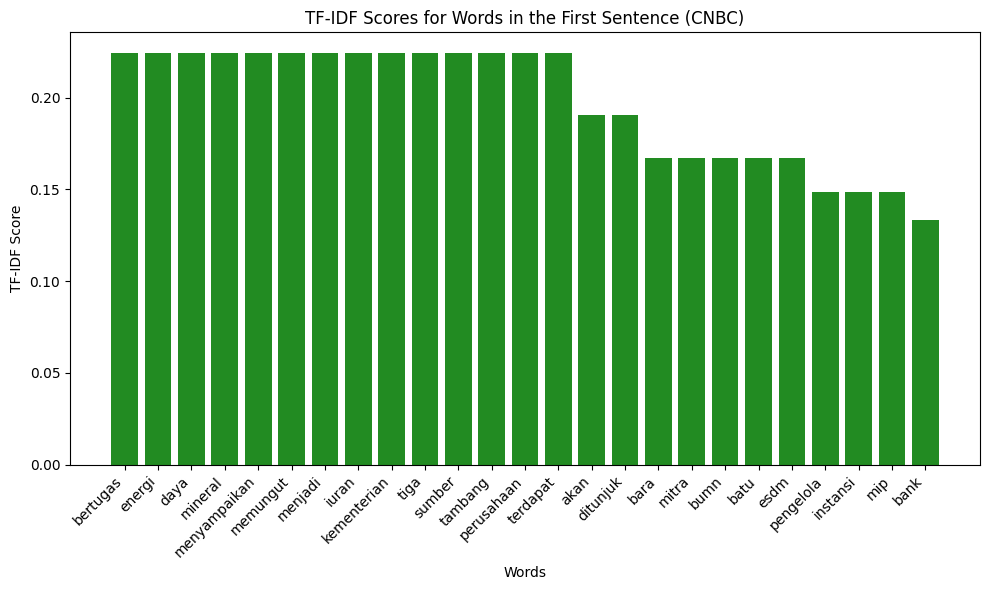

In [28]:
# To see the TF-IDF values for the first sentence (Matrix Analysis)
if cleaned_sentences3:
    # Memanggil fungsi helper get_tfidf_for_sentence yang sudah dibuat di 1A
    first_sentence_tfidf_df3 = get_tfidf_for_sentence(features3, 0, feature_names3)
    print("\nTF-IDF values for the first sentence (sorted):")
    print(first_sentence_tfidf_df3)

    # Visualize with Histogram
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df3['Feature'], first_sentence_tfidf_df3['TF-IDF'], color='forestgreen')
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Sentence (CNBC)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Calculate sentence score

In [29]:
# Variable initialization
sent_index3 = 0
sent_scores3 = []

# Calculate average TF-IDF score for each sentence
print("\n**Average TF-IDF Score for Each Sentence:**")
for i in features3:
    print(f"- Sentence {sent_index3 + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print("  Sum of TF-IDF scores:", sent_score)
    print("  Number of words:", sent_length)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print("  Average TF-IDF score:", avg_score)
    sent_scores3.append(avg_score)
    sent_index3 += 1



**Average TF-IDF Score for Each Sentence:**
- Sentence 1
  Sum of TF-IDF scores: 4.933939622253829
  Number of words: 25
  Average TF-IDF score: 0.19735758489015318
- Sentence 2
  Sum of TF-IDF scores: 2.1033067697137446
  Number of words: 5
  Average TF-IDF score: 0.42066135394274895
- Sentence 3
  Sum of TF-IDF scores: 4.194794187781941
  Number of words: 18
  Average TF-IDF score: 0.23304412154344117
- Sentence 4
  Sum of TF-IDF scores: 3.265987933146806
  Number of words: 11
  Average TF-IDF score: 0.2969079939224369
- Sentence 5
  Sum of TF-IDF scores: 5.116053458184405
  Number of words: 29
  Average TF-IDF score: 0.17641563648911743
- Sentence 6
  Sum of TF-IDF scores: 3.8101358202810895
  Number of words: 16
  Average TF-IDF score: 0.2381334887675681
- Sentence 7
  Sum of TF-IDF scores: 4.1988615843488795
  Number of words: 18
  Average TF-IDF score: 0.2332700880193822
- Sentence 8
  Sum of TF-IDF scores: 3.5742220163007374
  Number of words: 14
  Average TF-IDF score: 0.25530

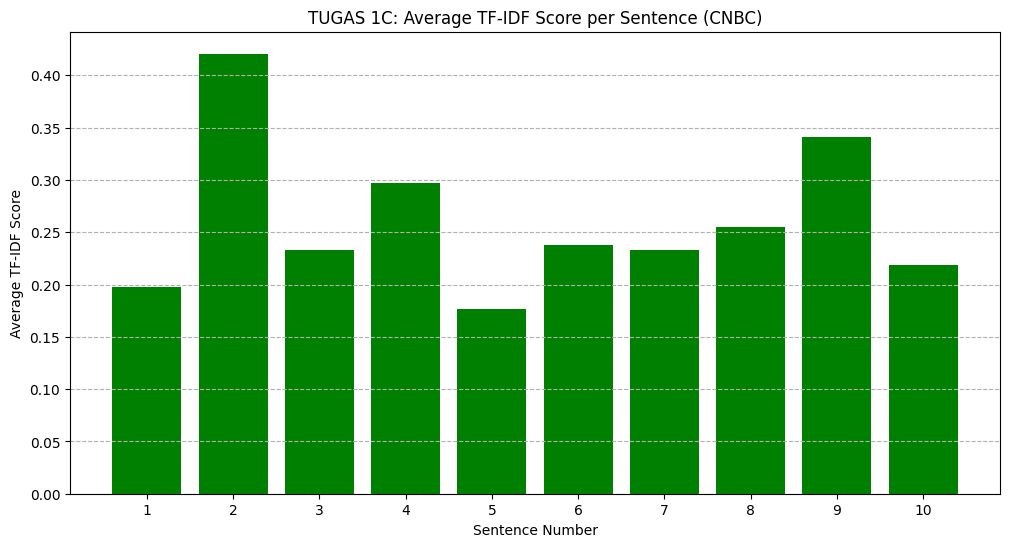

In [30]:
# Visualize Average Score Histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores3) + 1), sent_scores3, color='green')
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("TUGAS 1C: Average TF-IDF Score per Sentence (CNBC)")
plt.xticks(range(1, len(sent_scores3) + 1))
plt.grid(axis='y', linestyle='--')
plt.show()

### Define Threshold & Summarization Result

In [31]:
# Calculate the threshold
threshold3 = sum(sent_scores3) / len(sent_scores3) if sent_scores3 else 0
print("\nThreshold (Average of Sentence Scores):", threshold3)

# Final summary initialization
final_summ3 = ""

# Get summary sentences (logic: score >= threshold)
print("\n**Summary Sentences (CNBC News):**")
for index, data in enumerate(sent_scores3):
    if data >= threshold3:
        final_summ3 = final_summ3 + "\n" + sent_token3[index]
        print("- ", sent_token3[index])

print("\n**Final Summarization Result (1C):**")
print(final_summ3.strip())


Threshold (Average of Sentence Scores): 0.26105488977380104

**Summary Sentences (CNBC News):**
-  Ketiganya yakni Bank Mandiri, Bank BNI, dan Bank BRI.
-  Namun dalam pengelolaan dana kompensasi batu bara (DKB), pemerintah telah menyiapkan 3 Bank BUMN.
-  Sistem e-DKB akan diintegrasikan dengan sistem e-PNBP dalam skema pelaksanaan pemungutan dan penyaluran DKB.

**Final Summarization Result (1C):**
Ketiganya yakni Bank Mandiri, Bank BNI, dan Bank BRI.
Namun dalam pengelolaan dana kompensasi batu bara (DKB), pemerintah telah menyiapkan 3 Bank BUMN.
Sistem e-DKB akan diintegrasikan dengan sistem e-PNBP dalam skema pelaksanaan pemungutan dan penyaluran DKB.
